## Optimization Problem Formulation

We solve a simulation-based optimization problem to determine the optimal operating conditions of the PSA process. The goal is to maximize process productivity while satisfying constraints on product purity, recovery, and cyclic steady-state (CSS) convergence.

The decision variables are defined as

$$
x =
(L,\; P_0,\; \dot{n},\; t_{ads},\; \alpha,\; \beta,\; P_I,\; P_l)
$$

where

| Variable | Meaning |
|--------|--------|
| L | column length |
| P0 | adsorption pressure |
| ndot | feed flow rate |
| tads | adsorption time |
| alpha | pressurization fraction |
| beta | purge fraction |
| PI | intermediate pressure |
| Pl | low pressure |

Each variable is bounded within physically meaningful limits.

---

## Objective Function

The primary objective is to maximize the PSA productivity while optionally penalizing energy consumption.

$$
\max_x f(x)
$$

where

$$
f(x) =
\text{Productivity}(x) -
w_E \cdot \text{Energy}(x)
$$

In the current experiments the energy penalty weight $w_E$ is set to zero, so the optimization effectively maximizes productivity.

---

## Process Constraints

The optimization is subject to several process constraints.

### Purity constraint

$$
\text{Purity}(x) \ge P_{min}
$$

which is implemented as

$$
g_1(x) =
P_{min} - \text{Purity}(x) \le 0
$$

---

### Recovery constraint

$$
\text{Recovery}(x) \ge R_{min}
$$

implemented as

$$
g_2(x) =
R_{min} - \text{Recovery}(x) \le 0
$$

---

### Cyclic steady state (CSS)

The PSA cycle must reach cyclic steady state.

$$
g_3(x) =
CSS(x) - \epsilon_{css} \le 0
$$

where $CSS(x)$ measures the difference between consecutive cycles.

---

### Pressure ordering constraints

To ensure physically meaningful operation, the pressure levels must satisfy

$$
P_I \le P_0
$$

$$
P_l \le P_I
$$

---

## Optimization Method

Because the PSA model is evaluated through a cycle simulation, analytical gradients are not available. Therefore, we use a **trust-region sequential linear programming (SLP)** approach.

At each iteration:

1. The PSA cycle simulator evaluates the current operating point.
2. Gradients of the objective and constraints are estimated using finite differences.
3. A linearized trust-region subproblem is constructed.
4. The subproblem is solved using a linear programming solver.
5. The trust-region radius is updated depending on the improvement of the solution.

The LP subproblem is solved using the **GLPK solver** through Pyomo.

---

## Optimization Algorithm Workflow

The optimization procedure follows a trust-region sequential linear programming (SLP) framework applied to a simulation-based PSA process model.

The overall workflow of the algorithm is illustrated below.


Initial guess $x_0$  
↓  
PSA cycle simulation  
↓  
Evaluate objective and constraints  
↓  
Finite difference gradient estimation  
↓  
Construct trust-region LP subproblem  
↓  
Solve LP (Pyomo + GLPK)  
↓  
Candidate solution $x_{k+1}$  
↓  
Accept / Reject step  
↓  
Update trust region  
↓  
Check convergence


### Algorithm Summary

At each iteration $k$, the algorithm performs the following steps:

1. **Cycle simulation**  
   The PSA process is simulated using the current decision vector $x_k$.

2. **Objective and constraint evaluation**  
   Productivity, purity, recovery, and CSS error are computed from the simulation results.

3. **Gradient estimation**  
   Gradients of the objective and constraint functions are approximated using finite differences.

4. **Trust-region subproblem**  
   A local linear approximation of the nonlinear problem is constructed within a trust region.

5. **Linear programming solve**  
   The linearized subproblem is solved using Pyomo with the GLPK solver.

6. **Trust-region update**  
   The candidate solution is accepted if it improves the objective or reduces constraint violation; otherwise the trust region is reduced.

7. **Iteration**  
   The procedure repeats until convergence criteria are satisfied.

This approach allows efficient optimization of the PSA process even when analytical derivatives of the simulator are unavailable.

In [1]:
import sys
sys.path.append("..")

In [2]:
from pathlib import Path
import random

from psa_pyomo.model.column_model import ColumnDecisionSpace, VARIABLE_ORDER
from psa_pyomo.model.isotherm import IsothermParameters
from psa_pyomo.model.kinetics import KineticsParameters
from psa_pyomo.process.cycle_model import CycleConfig, CycleSimulator
from psa_pyomo.optimization.optimize_psa import OptimizationConfig, run_optimization

## Parameters

In [4]:
solver = 'glpk'
mat_index = 16
N = 5

purity_min = 0.8
recovery_min = 0.2
css_tol = 1e-4

max_iter = 20
delta0 = 0.25
fd_rel_step = 1e-3
css_max_iter = 30
energy_weight = 0.0

## Decision Variable Bounds

In [5]:
bounds = {
    'L': (1.0, 1.0),
    'P0': (2e5, 1e8),
    'ndot': (0.1, 5.0),
    'tads': (50.0, 800.0),
    'alpha': (0.15, 0.40),
    'beta': (0.10, 0.40),
    'PI': (1e4, 1e6),
    'Pl': (1e3, 1e5),
}

## Initial Point

In [6]:
initial_point = {
    'L': 1.0,
    'P0': 3.5e5,
    'ndot': 1.0,
    'tads': 300,
    'alpha': 0.25,
    'beta': 0.25,
    'PI': 3e5,
    'Pl': 1e4,
}

decision_space = ColumnDecisionSpace(bounds=bounds, initial_point=initial_point)
decision_space.validate()

In [7]:
cycle_config = CycleConfig(
    material_index=mat_index,
    n_grid=N,
    backend='python',
    css_max_iter=css_max_iter,
    css_tol=css_tol,
)

simulator = CycleSimulator(Path('..'), cycle_config)

In [8]:
optimization_config = OptimizationConfig(
    purity_min=purity_min,
    recovery_min=recovery_min,
    css_tol=css_tol,
    energy_weight=energy_weight,
    fd_rel_step=fd_rel_step,
    delta0=delta0,
    max_iter=max_iter,
    solver_name=solver,
)

In [9]:
best_point, best_eval = run_optimization(
    simulator,
    decision_space,
    optimization_config,
)

print('Best point:', best_point)
print('Evaluation:', best_eval)

iter=01 delta=0.3500 objective=0.197112 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=02 delta=0.4900 objective=0.252303 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=03 delta=0.6860 objective=0.329571 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=04 delta=0.9604 objective=0.437746 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=05 delta=1.3446 objective=0.589191 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=06 delta=1.8824 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=07 delta=0.9412 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=08 delta=0.4706 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=09 delta=0.2353 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=10 delta=0.1176 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=11 delta=0.0588 objective=0.788448 purity=0.899022 recovery=0.200000 css=2.37e-05
iter=12 delta=0.0294 objective=0.788448 pur

## Results Analysis/Visualization

The notebook visualizes the optimization progress using several figures:

- objective convergence  
- purity and recovery evolution  
- CSS error convergence  
- trust-region radius updates  

These plots provide insight into the convergence behavior of the optimization algorithm.

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../logs/optimization_iterations.csv")

# find iter=1
runs = df.index[df["iter"] == 1].tolist()

# index: last run
start = runs[-1]

# last run data
df_last = df.iloc[start:]

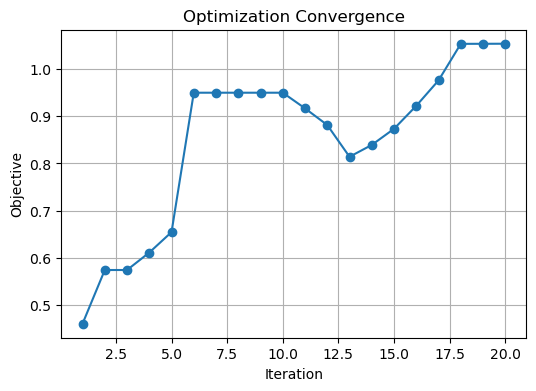

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(df_last["iter"], df_last["objective"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("Optimization Convergence")

plt.grid()

plt.show()

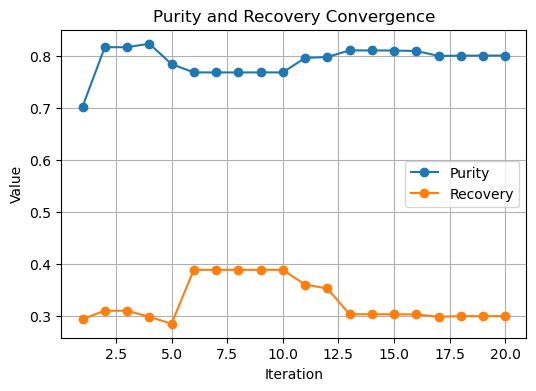

In [16]:
plt.figure(figsize=(6,4))

plt.plot(df_last["iter"], df_last["purity"], label="Purity", marker="o")
plt.plot(df_last["iter"], df_last["recovery"], label="Recovery", marker="o")

plt.xlabel("Iteration")
plt.ylabel("Value")
plt.title("Purity and Recovery Convergence")

plt.legend()
plt.grid()

plt.show()

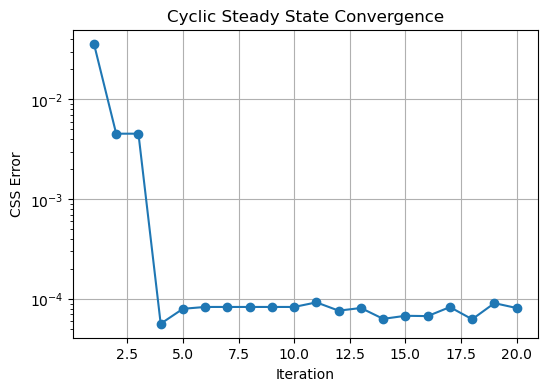

In [17]:
plt.figure(figsize=(6,4))

plt.plot(df_last["iter"], df_last["css_error"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("CSS Error")

plt.title("Cyclic Steady State Convergence")

plt.yscale("log")

plt.grid()

plt.show()

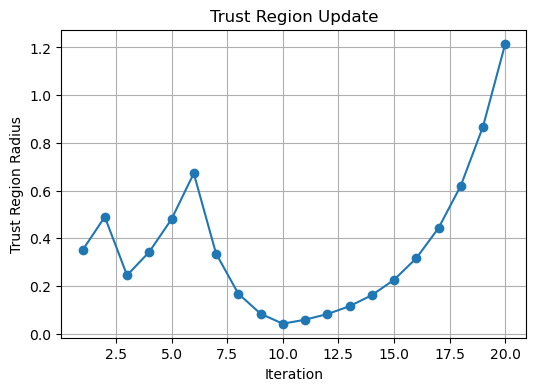

In [18]:
plt.figure(figsize=(6,4))

plt.plot(df_last["iter"], df_last["delta"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("Trust Region Radius")

plt.title("Trust Region Update")

plt.grid()

plt.show()

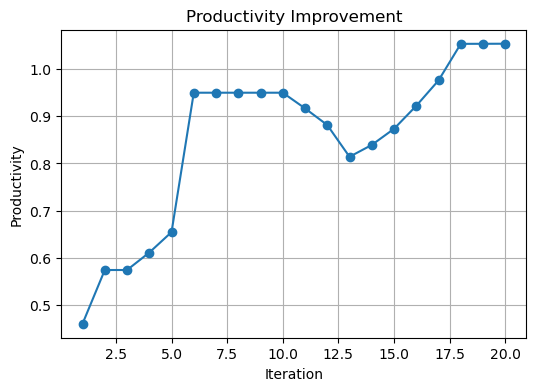

In [19]:
plt.figure(figsize=(6,4))

plt.plot(df_last["iter"], df_last["productivity"], marker="o")

plt.xlabel("Iteration")
plt.ylabel("Productivity")

plt.title("Productivity Improvement")

plt.grid()

plt.show()

In [21]:
import pandas as pd

result = pd.DataFrame({
    "variable": best_point.keys(),
    "value": best_point.values()
})

result

,variable,value
0,L,1.000000
1,P0,349995.919040
2,ndot,5.000000
3,tads,300.000000
4,alpha,0.175747
5,beta,0.100000
6,PI,299995.919040
7,Pl,9995.919040


In [23]:
best_iter = df_last.loc[df_last["objective"].idxmax()]

best_iter

iter             20.000000
accepted          1.000000
delta             1.215380
objective         1.053785
purity            0.800562
recovery          0.300040
css_error         0.000081
productivity      1.053785
energy          636.547270
Name: 18255, dtype: float64